In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pylab as plt

%matplotlib inline

from tyssue.core.sheet import Sheet

from tyssue import Sheet, Monolayer, config

from tyssue.topology.monolayer_topology import cell_division

from tyssue import ClosedMonolayerGeometry as geom
from tyssue import ClosedMonolayerGeometry 
from tyssue.solvers import QSSolver
from tyssue.generation import extrude


from tyssue.dynamics import effectors, model_factory

from tyssue.draw import sheet_view

from tyssue.io.hdf5 import save_datasets, load_datasets


import warnings
warnings.filterwarnings('ignore')

collision solver could not be imported You may need to install CGAL and re-install tyssue
CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version


In [2]:
datasets = load_datasets('small_ellipsoid.hf5')
specs = config.geometry.bulk_spec()

monolayer = Monolayer('ell', datasets, specs)
monolayer.reset_index()
monolayer.reset_topo()
geom.update_all(monolayer)


# ## Settings for the quasi-static model
model = model_factory([effectors.LumenVolumeElasticity,
                       effectors.VitellineElasticity,
                       effectors.CellVolumeElasticity,
                       effectors.CellAreaElasticity,
                       effectors.LineTension],
                      effectors.CellVolumeElasticity)

## Initial model settings
dyn_specs = {
    "settings": {
        "lumen_side": "basal",
        "lumen_prefered_volume": monolayer.settings["lumen_volume"],
        "lumen_volume_elasticity": 10.0,
        "threshold_length": 1e-2,
    },
    "cell": {
        "prefered_volume": monolayer.cell_df.vol.mean(),
        "prefered_area": monolayer.cell_df.area.mean(),        
        "volume_elasticity": 1.0,
        "area_elasticity": 1.0,
    },
    "edge": {
        "line_tension": 0.01,
        "ux": 0.0,
        "uy": 0.0,
        "uz": 0.0,
    }
}

monolayer.update_specs(dyn_specs)

In [3]:
def test_spherical_grad():
    sheet = generation.ellipsoid_sheet(1, 1, 1, 10)
    sheet.settings["geometry"] = "spherical"
    np.testing.assert_approx_equal(
        np.linalg.norm(height_grad(sheet), axis=1).mean(), 2, 2
    )

In [4]:
from tyssue import generation
from tyssue.dynamics.sheet_gradients import height_grad
from tyssue.geometry.sheet_geometry import EllipsoidGeometry

In [5]:
sheet = generation.ellipsoid_sheet(1, 1, 1, 10)
sheet.settings["geometry"] = "spherical"
EllipsoidGeometry.update_all(sheet)
np.testing.assert_approx_equal(
    np.linalg.norm(height_grad(sheet), axis=1).mean(), 1, 2
)

/home/u2175049/anaconda3/envs/CellPacking/lib/python3.11/site-packages/tyssue-0.9.0-py3.11-linux-x86_64.egg/tyssue/core/objects.py:279: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.cell_df["num_faces"] = self.edge_df.groupby("cell").apply(
/home/u2175049/anaconda3/envs/CellPacking/lib/python3.11/site-packages/tyssue-0.9.0-py3.11-linux-x86_64.egg/tyssue/core/objects.py:861: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this war

get_opposite_faces


In [6]:

monolayer.settings

{'geometry': 'cylindrical',
 'height_axis': 'z',
 'lumen_volume': 0.29248877463090095,
 'lumen_side': 'basal',
 'lumen_prefered_volume': 0.29248877463090095,
 'lumen_volume_elasticity': 10.0,
 'threshold_length': 0.01}

In [7]:
monolayer.settings['lumen_side'] = "basal"
geom.update_all(monolayer)

In [8]:
monolayer.settings["lumen_volume"]

0.29248877463090095

In [9]:
energies = model.compute_energy(monolayer, full_output=True)
print(*(f"{label.ljust(25)}: \t{np.sum(energy)/monolayer.Nc:.3e}"
      for label, energy in zip(model.labels, energies)), sep='\n')

Lumen volume elasticity  : 	0.000e+00
Cell Volume elasticity   : 	8.212e-05
Area elasticity          : 	7.713e-03
Line tension             : 	1.803e-01


In [10]:
solver = QSSolver(with_t1=False, with_t3=False, with_collisions=False)
res = solver.find_energy_min(monolayer, geom, model)

In [11]:
print(res["message"])

CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [3]:
def two_panels(monolayer):

    fig, (xy, zy) = plt.subplots(1, 2, sharey=True)
    fig, xy = sheet_view(monolayer.get_sub_sheet("apical"), mode="quick",
                         coords=['x', 'y'],
                         ax=xy, c='blue', alpha=0.3)
    fig, xy = sheet_view(monolayer.get_sub_sheet("basal"), mode="quick",
                         coords=['x', 'y'],
                         ax=xy, c='orange', alpha=0.3)
   
    fig, zy = sheet_view(monolayer.get_sub_sheet("apical"), mode="quick", 
                         coords=['z', 'x'],
                         ax=zy, c='blue', alpha=0.3)

    fig, zy = sheet_view(monolayer.get_sub_sheet("basal"), mode="quick", 
                     coords=['z', 'x'],
                     ax=zy, c='orange', alpha=0.3)

    xy.set_aspect('equal', 'box')
    zy.set_aspect('equal', 'box')
    fig.set_size_inches(12, 6)
    return fig, (xy, zy)


def panels(monolayer, side="apical"):

    fig, (xy, zy) = plt.subplots(1, 2, sharey=True)
    fig, xy = sheet_view(monolayer.get_sub_sheet(side), mode="quick",
                         coords=['x', 'y'],
                         ax=xy, c='blue', alpha=0.3)
   
    fig, zy = sheet_view(monolayer.get_sub_sheet(side), mode="quick", 
                         coords=['z', 'x'],
                         ax=zy, c='blue', alpha=0.3)

   
    xy.set_aspect('equal', 'box')
    zy.set_aspect('equal', 'box')
    fig.set_size_inches(12, 6)
    return fig


# Create 3D from scratch

In [4]:
from tyssue.geometry.sheet_geometry import SheetGeometry

from tyssue.geometry.sheet_geometry import ClosedSheetGeometry, EllipsoidGeometry
from tyssue.generation import ellipsoid_sheet


class EllipsoidClosedMonolayerGeometry(ClosedMonolayerGeometry):
    @classmethod
    def update_all(cls, eptm):
        """
        Updates the eptm geometry by updating:
        * the edge vector coordinates
        * the edge lengths
        * the face centroids
        * the normals to each edge associated face
        * the face areas
        * the cell areas
        * the vertices heights (depends on geometry)
        * the face volumes (depends on geometry)

        """
        super().update_all(eptm)
        cls.update_height(eptm)

    @staticmethod
    def update_height(eptm):

        a, b, c = eptm.settings["abc"]
        eptm.vert_df["theta"] = np.arcsin((eptm.vert_df.z / c).clip(-1, 1))
        eptm.vert_df["vitelline_rho"] = a * np.cos(eptm.vert_df["theta"])
        eptm.vert_df["basal_shift"] = (
            eptm.vert_df["vitelline_rho"] - eptm.specs["vert"]["basal_shift"]
        )
        eptm.vert_df["delta_rho"] = (
            np.linalg.norm(eptm.vert_df[["x", "y"]], axis=1)
            - eptm.vert_df["vitelline_rho"]
        ).clip(lower=0)

        SheetGeometry.update_height(eptm)

    # @staticmethod
    # def scale(eptm, scale, coords):
    #     SheetGeometry.scale(eptm, scale, coords)
    #     eptm.settings["abc"] = [u * scale for u in eptm.settings["abc"]]

In [5]:
from scipy.special import ellipkinc, ellipeinc

def calculate_area_ellipsoid(a,b,c):
    phi = np.arccos(c/a)
    m = 1

    temp = ellipeinc(phi, m)*np.sin(phi)**2 + ellipkinc(phi, m)*np.cos(phi)**2
    ellipsoid_area = 2*np.pi*(c**2 + a*b*temp/np.sin(phi))
    return ellipsoid_area


def calculate_lumen_vol(eptm):
    """ """
    lumen_edges = eptm.edge_df[
        eptm.edge_df.segment == eptm.settings.get("lumen_side", "basal")
    ].copy()
    lumen_pos_faces = lumen_edges[["f" + c for c in eptm.coords]].values
    lumen_sub_vol = (
        np.sum((lumen_pos_faces) * lumen_edges[eptm.ncoords].values, axis=1) / 6
    )
    return -lumen_sub_vol.sum()


In [6]:
solver = QSSolver(with_t1=False, with_t3=True, with_collisions=False)


a = 24
b = 24
c = 42
ellipso = ellipsoid_sheet(a=a, b=b, c=c, n_zs=34, pos_err=0.02, phase_err=0.1)


print(ellipso.Nc)

dyn_specs = {
    "settings": {
        "lumen_side": "basal",
        # "lumen_prefered_volume": np.sum(ellipso.upcast_srce(ellipso.vert_df["height"]) * ellipso.edge_df["sub_area"])*1.1,
        "lumen_prefered_volume": 4/3*np.pi*a*b*c*0.98, 
        "lumen_volume": np.sum(ellipso.upcast_srce(ellipso.vert_df["height"]) * ellipso.edge_df["sub_area"]),
        "lumen_volume_elasticity": 1e-1,
        "threshold_length": 1e-2,
        "abc":[a,b,c],
        "geometry":"cylindrical", #"spherical",
        'height_axis': 'z',
        'vitelline_space': 0.2,
    },
    "face":{
        "area_elasticity":1., 
        "perimeter_elasticity":0.5, 
        "prefered_area" : 9,
        "prefered_perimeter" : 2.*np.sqrt(9),
    },
    "edge": {
        "line_tension": 0.01,
        "ux": 0.0,
        "uy": 0.0,
        "uz": 0.0,
    },
    "vert":{
        "vitelline_K":100.,
        'height': 0,
        'basal_shift': 0,
        'delta_rho': 1.,
        
    }
}
ellipso.update_specs(dyn_specs)

model = model_factory([
    effectors.LumenVolumeElasticity,
                       effectors.VitellineElasticity,
                       effectors.FaceAreaElasticity,
                       effectors.PerimeterElasticity,
                      ],)

EllipsoidGeometry.update_all(ellipso)
res = solver.find_energy_min(ellipso, EllipsoidGeometry, model, options={"gtol": 1e-8})

ellipso.sanitize()

EllipsoidGeometry.update_all(ellipso)
res = solver.find_energy_min(ellipso, EllipsoidGeometry, model, options={"gtol": 1e-8})

get_opposite_faces
1194


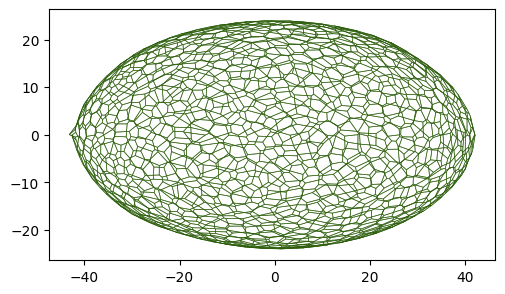

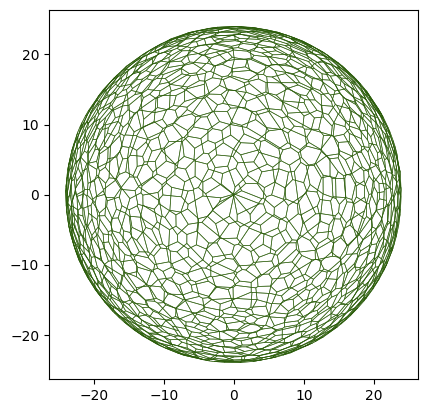

In [7]:
fig, ax0 = sheet_view(
    ellipso, 
    coords=["z", "y"],
)
fig, ax1 = sheet_view(
    ellipso, 
    coords=["x", "y"],
)

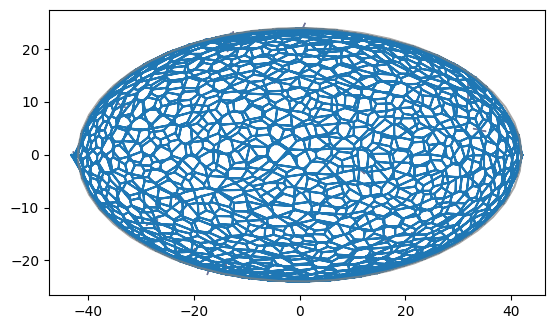

In [8]:
from tyssue.draw.plt_draw import plot_forces, plot_scaled_energies
fig, ax = plot_forces(ellipso, ClosedSheetGeometry, model, ["z", "x"], 0.1 )

thetas = np.linspace(0, 2 * np.pi)
ax.plot(c * np.cos(thetas), a * np.sin(thetas), color='grey', alpha=0.7)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

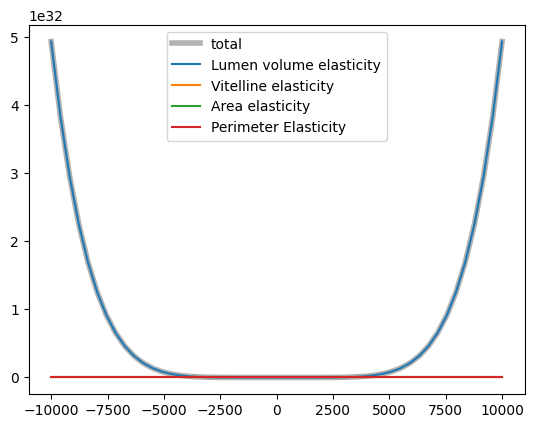

In [9]:
plot_scaled_energies(ellipso, ClosedSheetGeometry, model, np.linspace(-10000,10000))

In [10]:
ellipso.settings

{'abc': [24, 24, 42],
 'lumen_volume': 99306.79655946203,
 'lumen_side': 'basal',
 'lumen_prefered_volume': 99308.50838150852,
 'lumen_volume_elasticity': 0.1,
 'threshold_length': 0.01,
 'geometry': 'cylindrical',
 'height_axis': 'z',
 'vitelline_space': 0.2}

In [11]:
from tyssue.utils.decorators import face_lookup
from tyssue.geometry.sheet_geometry import SheetGeometry
from tyssue.topology.sheet_topology import cell_division

from tyssue.behaviors.sheet.actions import contract, exchange, remove


default_division_spec = {
    "face_id": -1,
    "face": -1,
    "growth_rate": 0.1,
    "critical_area": 3,
    "angle":None,
    "geom": SheetGeometry,
}


@face_lookup
def division(sheet, manager, **kwargs):
    """Cell division happens through cell growth up to a critical volume,
    followed by actual division of the face.

    Parameters
    ----------
    sheet : a `Sheet` object
    manager : an `EventManager` instance
    face_id : int,
      index of the mother face
    growth_rate : float, default 0.1
      rate of increase of the prefered volume
    critical_vol : float, default 2.
      volume at which the cells stops to grow and devides

    """
    division_spec = default_division_spec
    division_spec.update(**kwargs)

    face = division_spec["face"]

    #division_spec["critical_area"] *= sheet.specs["face"]["prefered_area"]

    #print(sheet.face_df.loc[face, "area"], division_spec["critical_area"])

    #if sheet.face_df.loc[face, "area"] < division_spec["critical_area"]:
        #grow(sheet, face, division_spec["growth_rate"])
        #manager.append(division, **division_spec)
    #else:
    daughter = cell_division(sheet, face, division_spec["geom"], division_spec["angle"])
    sheet.face_df.loc[daughter, "id"] = sheet.face_df.id.max() + 1
    sheet.face_df.loc[daughter, 'prefered_area'] = (sheet.face_df.loc[face, 'prefered_area']/2 +
                                                     np.random.normal(scale=5))
    sheet.face_df.loc[face,'prefered_area'] -= (sheet.face_df.loc[daughter, 'prefered_area']
                                                +np.abs(np.random.normal(scale=1.5)))
        
        
def grow(sheet, face, growth_rate):
    sheet.face_df.loc[face,"prefered_area"] *= 1+growth_rate

In [12]:
from tyssue.behaviors.event_manager import EventManager

ellipso.face_df['id']=ellipso.face_df.index
manager = EventManager('face')

division_settings = {    
    "face_id": -1,
    "growth_rate": 1.5,
    "critical_area": 2,
    "geom": EllipsoidGeometry}

angle = np.random.random(ellipso.Nf)*(np.pi/3)+(np.pi/3)

for i in ellipso.face_df.index:
    division_settings.update(
        {
            'face_id': i,
            'angle':angle[i],
        }
    )
    manager.append(division, **division_settings)

i = 0
while manager.current:
    manager.update()

    manager.execute(ellipso)

    res = solver.find_energy_min(ellipso, EllipsoidGeometry, model, options={"gtol": 1e-8})

    # add noise on vertex position to avoid local minimal.
    ellipso.vert_df[
        ['x', 'y']] += np.random.normal(scale=1e-3, size=(ellipso.Nv, 2))
    EllipsoidGeometry.update_all(ellipso)

    i=i+1

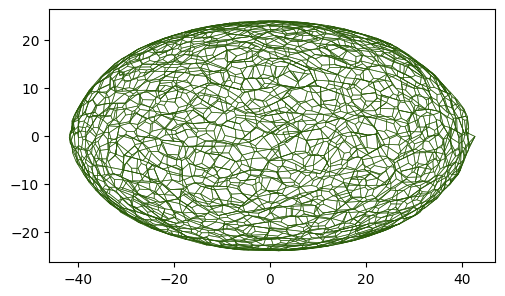

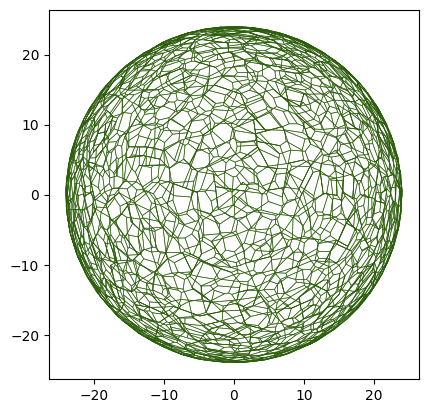

In [13]:
# res = solver.find_energy_min(ellipso, EllipsoidGeometry, model, options={"gtol": 1e-8})
fig, ax0 = sheet_view(
    ellipso, 
    coords=["z", "y"],
)
fig, ax1 = sheet_view(
    ellipso, 
    coords=["x", "y"],
)

In [28]:
from tyssue import Monolayer, MonolayerGeometry, ClosedMonolayerGeometry
from tyssue.generation import extrude

datasets = extrude(ellipso.datasets, method='homotecy', scale=0.7)

mono_ellipso = Monolayer('mono_ell', datasets)
ClosedMonolayerGeometry.update_all(mono_ellipso)

dyn_specs = {
    "settings": {
        "lumen_side": "basal",
        "lumen_prefered_volume": 37000,
        "lumen_volume":  calculate_lumen_vol(mono_ellipso),
        "lumen_volume_elasticity": 1.0e-3,
        "threshold_length": 1e-2,
        "abc":[a,b,c],
        # "abc":[ellipso.vert_df["x"].max()*0.7,
        #        ellipso.vert_df["y"].max()*0.7,
        #        ellipso.vert_df["z"].max()*0.7],
        'threshold_length': 0.1,
         'p_4': 1,
         'p_5p': 1,
        "geometry":"cylindrical",
        'height_axis': 'z',
        'vitelline_space': 0.2,
    },
    "cell": {
        "prefered_volume": 15.,
        "volume_elasticity": 0.5,
    },
    "face":{

        "area_elasticity":1., 
        "perimeter_elasticity":0.5, 
    },
    "edge": {
        "line_tension": 0.01,
        "ux": 0.0,
        "uy": 0.0,
        "uz": 0.0,
    },
    "vert":{
        "vitelline_K":280.,
        'height': 0,
        'basal_shift': 0,
        'delta_rho': 30,
        
    }
}

model = model_factory([
                    effectors.LumenVolumeElasticity,
                       # effectors.VitellineElasticity,
                       effectors.CellVolumeElasticity,
                       effectors.FaceAreaElasticity,
                        effectors.PerimeterElasticity,
                       # effectors.LineTension
                      ],
                      effectors.CellVolumeElasticity)

shape_index=3.5
mono_ellipso.update_specs(dyn_specs)
# mono_ellipso.cell_df['prefered_volume'] = mono_ellipso.cell_df.loc[0,'volume']

mono_ellipso.face_df['prefered_area'] = ellipso.face_df['area'].mean()
mono_ellipso.face_df['prefered_perimeter'] = shape_index*np.sqrt(mono_ellipso.face_df['prefered_area'])


solver = QSSolver(with_t1=False, with_t3=False, with_collisions=False)

EllipsoidClosedMonolayerGeometry.update_all(mono_ellipso)
res = solver.find_energy_min(mono_ellipso, EllipsoidClosedMonolayerGeometry, model)


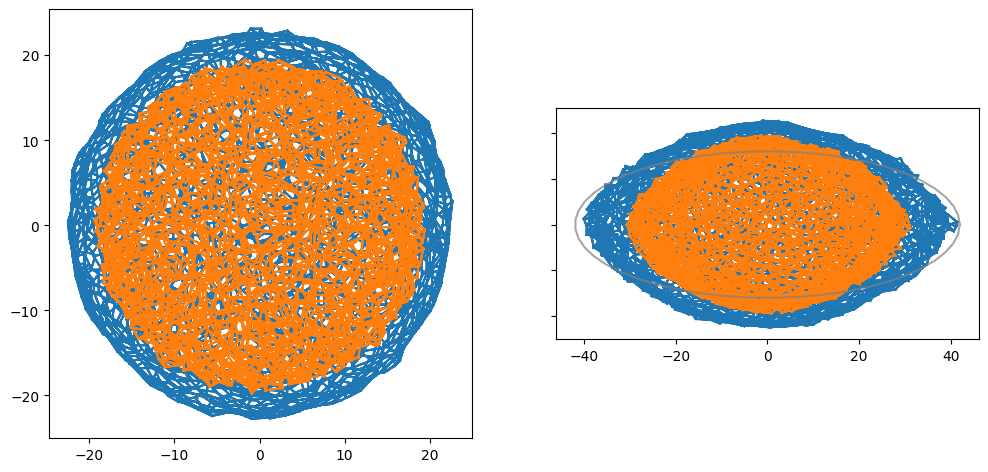

In [29]:
fig, axes = two_panels(mono_ellipso)

thetas = np.linspace(0, 2 * np.pi)
axes[1].plot(c * np.cos(thetas), a * np.sin(thetas), color='grey', alpha=0.7)

In [30]:
from pathlib import Path
import os 

from tyssue.behaviors.event_manager import EventManager
from tyssue.behaviors.sheet.basic_events import reconnect, reconnect_3D
from tyssue.io.hdf5 import save_datasets

SIM_DIR = Path('/mnt/sda1/Sophie/1-CellPacking/PRE_Revision/ellipsoid/')
sim_save_dir = SIM_DIR
try:
    os.mkdir(sim_save_dir)
except FileExistsError:
    pass


SIM_DIR = Path('/mnt/sda1/Sophie/1-CellPacking/PRE_Revision/ellipsoid/24_48')
sim_save_dir = SIM_DIR
try:
    os.mkdir(sim_save_dir)
except FileExistsError:
    pass

model = model_factory([
                    effectors.LumenVolumeElasticity,
                       effectors.VitellineElasticity,
                       effectors.CellVolumeElasticity,
                       effectors.FaceAreaElasticity,
                        effectors.PerimeterElasticity,
                       # effectors.LineTension
                      ],
                      effectors.CellVolumeElasticity)
manager = EventManager('face')#, track_event=False)
manager.append(reconnect_3D)
a,b,c = 29, 29, 29

for i in range(100):
    if i%10 == 0:
        if a > 23 : 
            a-=1
            b-=1
            c+=1
        dyn_specs = {
        "settings": {
            "abc":[a,b,c],
        }
        }
        mono_ellipso.update_specs(dyn_specs)
        EllipsoidClosedMonolayerGeometry.update_all(mono_ellipso)

        
    print('------------TEMPS------------')
    print(i)
    manager.execute(mono_ellipso)
    
    res = solver.find_energy_min(mono_ellipso, EllipsoidClosedMonolayerGeometry, model, options={"gtol": 1e-8})
    
    if res.success is False:
        print (i, res.success)

    mono_ellipso.vert_df[["x", "y", "z"]] += np.random.normal(scale=1e-3, size=(mono_ellipso.Nv, 3))
    EllipsoidClosedMonolayerGeometry.update_all(mono_ellipso)
    
    save_datasets(os.path.join(sim_save_dir,'monolayer'+str(i)+'.hf5'), mono_ellipso)

------------TEMPS------------
0
------------TEMPS------------
1
------------TEMPS------------
2
------------TEMPS------------
3
------------TEMPS------------
4
------------TEMPS------------
5
------------TEMPS------------
6
------------TEMPS------------
7
------------TEMPS------------
8
------------TEMPS------------
9
------------TEMPS------------
10
------------TEMPS------------
11
------------TEMPS------------
12
------------TEMPS------------
13
------------TEMPS------------
14
------------TEMPS------------
15
------------TEMPS------------
16
------------TEMPS------------
17
------------TEMPS------------
18
------------TEMPS------------
19
------------TEMPS------------
20
------------TEMPS------------
21
------------TEMPS------------
22
------------TEMPS------------
23
------------TEMPS------------
24
------------TEMPS------------
25
------------TEMPS------------
26
------------TEMPS------------
27
------------TEMPS------------
28
------------TEMPS------------
29
------------TEMPS---

In [31]:
mono_ellipso.settings

{'lumen_volume': 37019.49620792128,
 'lumen_side': 'basal',
 'lumen_prefered_volume': 37000,
 'lumen_volume_elasticity': 0.001,
 'threshold_length': 0.1,
 'abc': [23, 23, 35],
 'p_4': 1,
 'p_5p': 1,
 'geometry': 'cylindrical',
 'height_axis': 'z',
 'vitelline_space': 0.2}

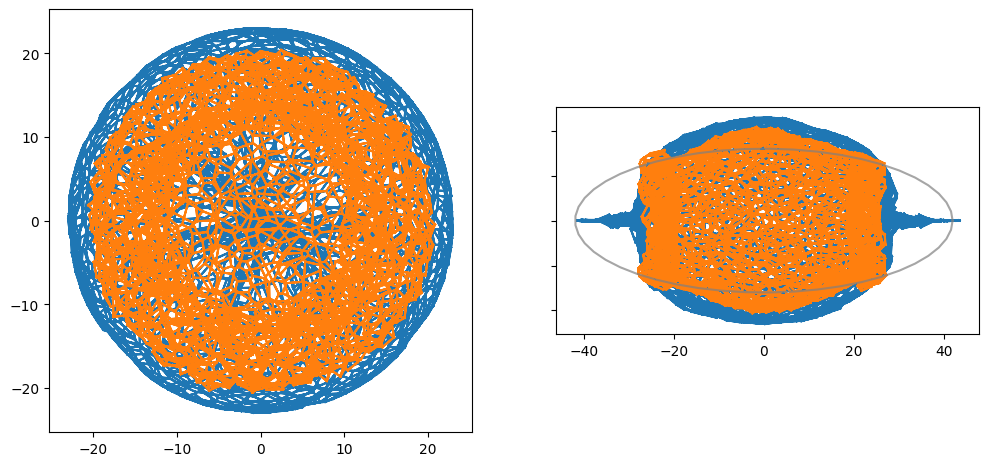

In [32]:
fig, axes = two_panels(mono_ellipso)

thetas = np.linspace(0, 2 * np.pi)
a = 16
b = 16
c = 42
axes[1].plot(c * np.cos(thetas), a * np.sin(thetas), color='grey', alpha=0.7)

In [27]:
mono_ellipso.cell_df

,x,y,z,is_alive,area,volume,num_faces,id,num_ridges,prefered_volume,volume_elasticity
cell,,,,,,,,,,,
0,18.043272,-8.488932,-13.407202,1,42.107973,12.186267,9,0,42,40.0,0.5
1,16.343374,-11.311384,-13.216357,1,49.950753,12.940825,8,1,36,40.0,0.5
2,16.548722,-9.706874,-15.610450,1,44.989733,14.352058,8,2,36,40.0,0.5
3,-2.548088,-15.247713,21.563763,1,103.848072,26.645201,9,3,42,40.0,0.5
4,-3.672217,-14.723304,21.569328,1,82.801492,31.081688,8,4,36,40.0,0.5
...,...,...,...,...,...,...,...,...,...,...,...
2383,-7.501612,20.866926,-0.229529,1,26.751336,7.752040,11,2383,54,40.0,0.5
2384,-1.633171,-8.594924,25.415287,1,113.372486,25.379914,8,2384,36,40.0,0.5
2385,0.190886,-13.770731,22.981687,1,95.275947,26.266608,7,2385,30,40.0,0.5


In [20]:
mono_ellipso.cell_df.mean()

x                       0.100203
y                       0.232976
z                      -0.103108
is_alive                1.000000
area                  178.868066
volume                 36.573757
num_faces               7.994975
id                   1193.500000
num_ridges             35.969849
prefered_volume        40.000000
volume_elasticity       0.500000
dtype: float64

(<Figure size 640x480 with 1 Axes>, <Axes: >)

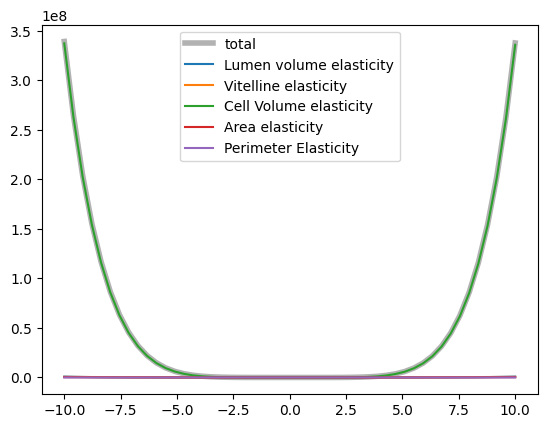

In [21]:
plot_scaled_energies(mono_ellipso, EllipsoidClosedMonolayerGeometry, model, np.linspace(-10,10))

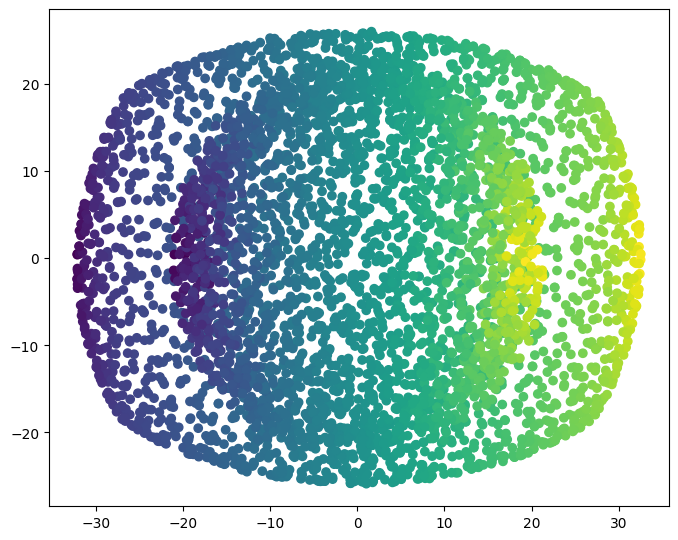

In [374]:
def f(sx,sy,sz, tx,ty,tz):
    return np.linalg.norm([sx-tx, sy-ty, sz-tz])
res_edges = mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="lateral"].apply(lambda x: f(x.sx, x.sy, x.sz, x.tx, x.ty, x.tz), axis=1)
res_basal = mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="lateral"].apply(lambda x: f(x.sx, x.sy, x.sz, 0, 0, 0), axis=1)

theta = np.arcsin((mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="lateral"]["sz"] / c).clip(-1, 1))

fig, ax = plt.subplots()
ax.scatter(mono_ellipso.vert_df["z"], mono_ellipso.vert_df["x"], c=np.arcsin((mono_ellipso.vert_df["z"] / mono_ellipso.vert_df.apply(lambda x: f(x.x, x.y, x.z, 0, 0, 0), axis=1)).clip(-1, 1)))

ax.set_aspect('equal', 'box')

In [352]:
def cart2sph(x,y,z):
    XsqPlusYsq = x**2 + y**2
    r = np.sqrt(XsqPlusYsq + z**2)               # r
    elev = np.arctan2(z,np.sqrt(XsqPlusYsq))     # theta
    az = np.arctan2(y,x)                           # phi
    return [x,y,z, r, elev, az]
res = mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="lateral"].apply(lambda x: cart2sph(x.sx-x.tx, x.sy-x.ty, x.sz-x.tz), axis=1)

In [255]:
res = pd.DataFrame(res.tolist(), columns=["x","y","z","r", "elev", "az"])

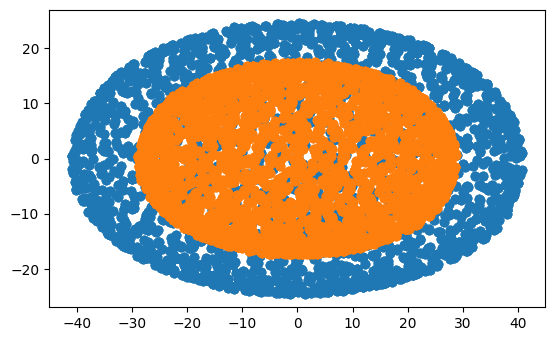

In [256]:
fig, ax = plt.subplots()
ax.scatter(mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="apical"]["sz"], mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="apical"]["sy"], 
           )
ax.scatter(mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="basal"]["sz"], mono_ellipso.edge_df[mono_ellipso.edge_df["segment"]=="basal"]["sy"], 
           )

ax.set_aspect('equal', 'box')

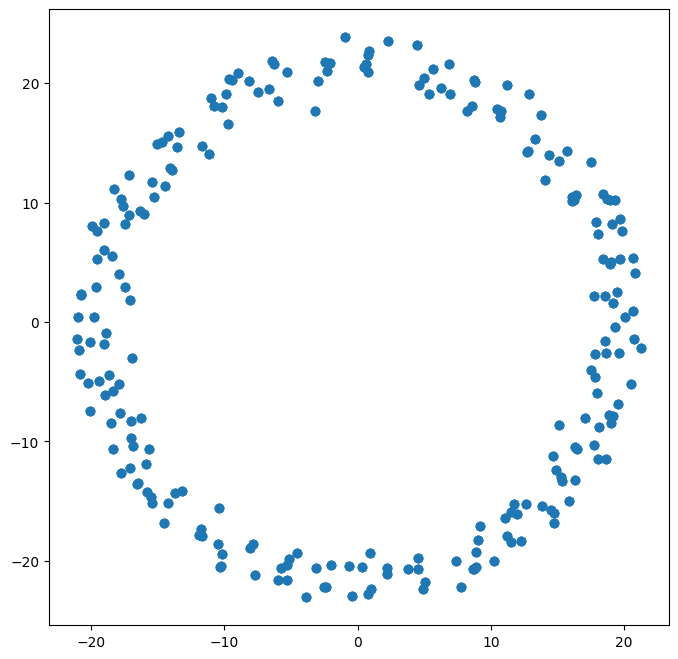

In [375]:
plt.scatter(mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="basal") & (mono_ellipso.edge_df["sy"]>-2) & (mono_ellipso.edge_df["sy"]<2)]['sz'],
            mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="basal") & (mono_ellipso.edge_df["sy"]>-2) & (mono_ellipso.edge_df["sy"]<2)]['sx'])

In [376]:
import shapely.geometry as geom
import numpy as np

coords = mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="basal") & (mono_ellipso.edge_df["sy"]>-2) & (mono_ellipso.edge_df["sy"]<2)][['sx','sz']]

line = geom.LineString(coords)
point = geom.Point(0.8, 10.5)

# Note that "line.distance(point)" would be identical
print(point.distance(line))

0.23947529340969792


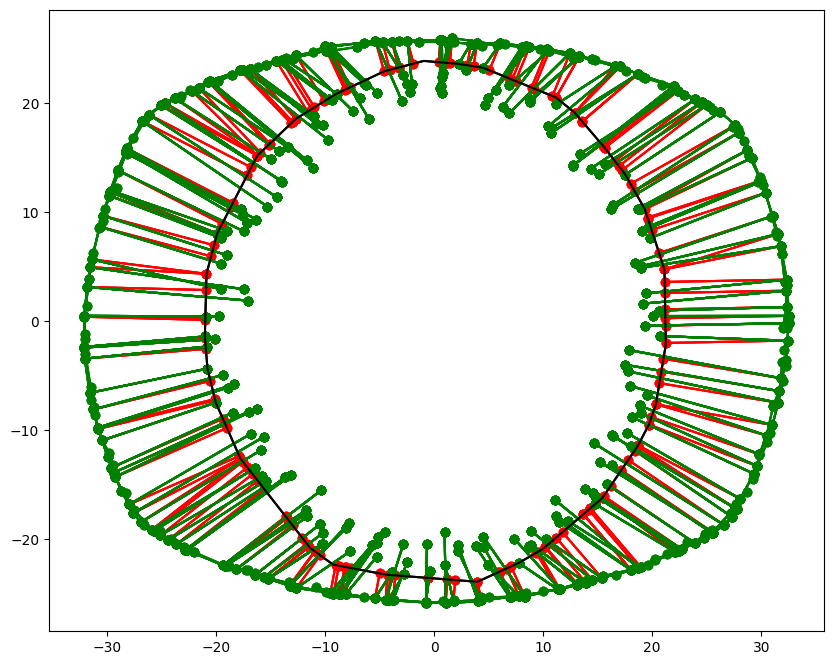

In [377]:
import numpy as np
import shapely.geometry as geom
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

coords_or = mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="basal") ][['sz','sx']].to_numpy()

ch = ConvexHull(coords_or, True)
coords = ch.simplices
list_vertices = ch.vertices
list_vertices = np.concatenate([list_vertices, [ch.vertices[0]]])

line = geom.LineString(coords_or[list_vertices])

fig, ax = plt.subplots()
# ax.scatter(*coords_or.T)
ax.plot(coords_or[list_vertices,0], coords_or[list_vertices,1], color="black")
# ax.scatter(*coords.T)
ax.axis('equal')

points = mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="apical") & (mono_ellipso.edge_df["sy"]>-2) & (mono_ellipso.edge_df["sy"]<2)][['sz','sx']].to_numpy()
for p in points:
    x,y = p
    point = geom.Point(x, y)
    distance = line.distance(point)

    point_on_line = line.interpolate(line.project(point))
    ax.plot([point.x, point_on_line.x], [point.y, point_on_line.y], 
                 color='red', marker='o',)
    fig.canvas.draw()



for v in mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="apical")& (mono_ellipso.edge_df["sy"]>-2) & (mono_ellipso.edge_df["sy"]<2)]['srce']:
    for i in range(6):
        ax.plot([mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="lateral") & (mono_ellipso.edge_df["srce"]==v)].iloc[i]["sz"], 
                mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="lateral") & (mono_ellipso.edge_df["srce"]==v)].iloc[i]["tz"]], 
                [mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="lateral") & (mono_ellipso.edge_df["srce"]==v)].iloc[i]["sx"], 
                mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="lateral") & (mono_ellipso.edge_df["srce"]==v)].iloc[i]["tx"]], 
                     color='green', marker='o', )


ax.plot(coords_or[list_vertices,0], coords_or[list_vertices,1], color="black")

ax.set_aspect('equal', 'box')
fig.set_size_inches(10,10)
plt.show()

In [319]:
# def get_normal(a,b,c, x,y):
#     t=np.arctan2(2*y/c, x/a)
#     nx=a*np.sin(t)
#     ny=c*np.cos(t)
    
#     # theta = np.arctan2(2*y/a, x/c)
#     # ny = c * np.sin(theta)
#     # nx = a * np.cos(theta)
#     return nx,ny

# print(get_normal(a,b,c, point.x*0.7, point.y*0.7))
# print(a,b,c, point.x, point.y)


def find_tangent_lines(
    center,
    semi_axes,
    rotation,
    reference_point,
):
    """Find the Ellipse's two tangents that go through a reference point.

    Args:
        center: The center of the ellipse.
        semi_axes: The semi-major and semi-minor axes of the ellipse.
        rotation: The counter-clockwise rotation of the ellipse in radians.
        reference_point: The coordinates of the reference point.

    Returns:
        (m1, h1): Slope and intercept of the first tangent.
        (m2, h2): Slope and intercept of the second tangent.
    """
    x0, y0 = center
    a, b = semi_axes
    s, c = np.sin(rotation), np.cos(rotation)
    p0, q0 = reference_point

    A = (-a**2*s**2 - b**2*c**2 + (y0-q0)**2)
    B = 2*(c*s*(a**2-b**2) - (x0-p0)*(y0-q0))
    C = (-a**2*c**2 - b**2*s**2 + (x0-p0)**2)

    if B**2 - 4*A*C < 0:
        raise ValueError('Reference point lies inside the ellipse')

    t1, t2 = (
        (-B + np.sqrt(B**2 - 4*A*C))/(2*A),
        (-B - np.sqrt(B**2 - 4*A*C))/(2*A),
    )
    return (
        (1/t1, q0 - p0/t1),
        (1/t2, q0 - p0/t2),
    )
print([point.x, point.y])
find_tangent_lines([0,0], [a,c],[0],[point.x*0.7, point.y*0.7])



[-37.92571943393649, -9.21687491039886]


((array([-839.1963576]), array([-22285.43973816])),
 (array([841.85609984]), array([22343.14695999])))

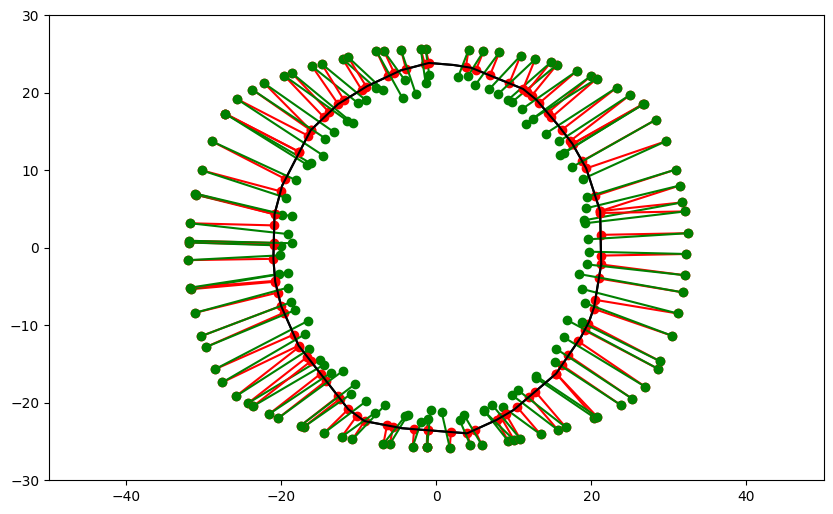

In [379]:
import numpy as np
import shapely.geometry as geom
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

coords_or = mono_ellipso.edge_df[(mono_ellipso.edge_df["segment"]=="basal") ][['sz','sx']].to_numpy()

ch = ConvexHull(coords_or, True)
coords = ch.simplices
list_vertices = ch.vertices
list_vertices = np.concatenate([list_vertices, [ch.vertices[0]]])

line = geom.LineString(coords_or[list_vertices])

fig, ax = plt.subplots()
# ax.scatter(*coords_or.T)
ax.plot(coords_or[list_vertices,0], coords_or[list_vertices,1], color="black")
# ax.scatter(*coords.T)
ax.axis('equal')


def getAngle(a, b, c):
    ang = (np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0]))*180/np.pi
    return ang

angle = []
z_pos= []
cell_height = []

for c in range (mono_ellipso.Nf):
    try:
        if mono_ellipso.cell_df.loc[c]["y"]>-2 and mono_ellipso.cell_df.loc[c]["y"]<2:
        
            f1 = mono_ellipso.edge_df[(mono_ellipso.edge_df["cell"]==c) & (mono_ellipso.edge_df["segment"]=="apical")]["face"].unique()[0]
            f2 = mono_ellipso.edge_df[(mono_ellipso.edge_df["cell"]==c) & (mono_ellipso.edge_df["segment"]=="basal")]["face"].unique()[0]
    
            point = geom.Point(mono_ellipso.face_df.loc[f1][list("zx")].to_numpy())
            distance = line.distance(point)

            
            point_on_line = line.interpolate(line.project(point))

            # plot projection
            ax.plot([point.x, point_on_line.x], [point.y, point_on_line.y], 
                         color='red', marker='o',)    

            # nx, ny = get_normal(a,b,c, point.x, point.y)
            # ax.plot([point.x, nx], [point.y, ny], 
            #              color='orange', marker='o',) 

            # plot cell axis
            ax.plot([mono_ellipso.face_df.loc[f1]["z"], mono_ellipso.face_df.loc[f2]["z"]], 
                    [mono_ellipso.face_df.loc[f1]["x"], mono_ellipso.face_df.loc[f2]["x"]], 
                         color='green', marker='o',)    

            angle.append(getAngle((point_on_line.x, point_on_line.y), (point.x, point.y), (mono_ellipso.face_df.loc[f2]["z"], mono_ellipso.face_df.loc[f2]["x"])))
            cell_height.append(np.linalg.norm(mono_ellipso.face_df.loc[[f1,f2]][list("xyz")].diff(axis=0), axis=1)[1])
            z_pos.append(mono_ellipso.cell_df.loc[c]["z"])
    except: 
        pass


ax.plot(coords_or[list_vertices,0], coords_or[list_vertices,1], color="black")
ax.set_xlim(-50,50)
ax.set_ylim(-30,30)
ax.set_aspect('equal', 'box')
fig.set_size_inches(10,10)
plt.show()

Text(0, 0.5, 'cell height')

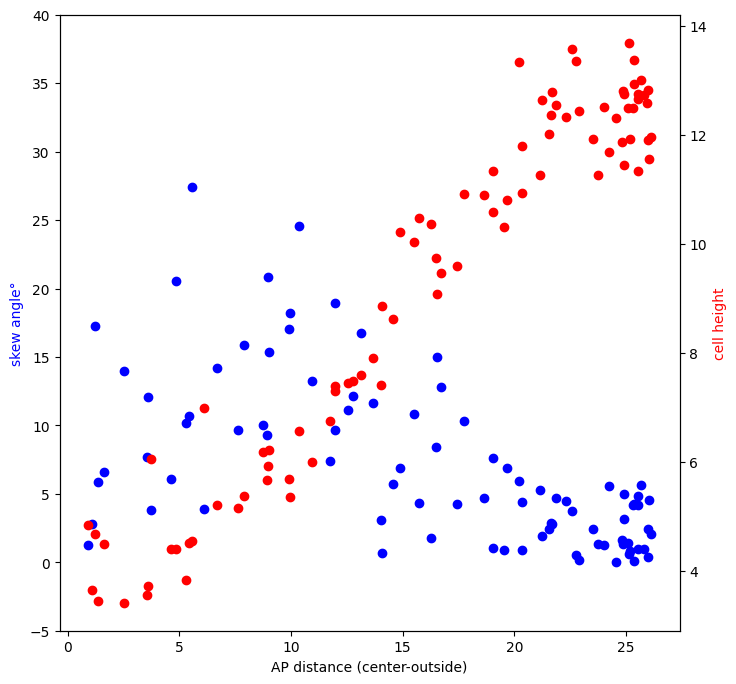

In [380]:
fig, ax =plt.subplots()

ax.scatter(np.abs(np.array(z_pos)), np.abs(angle), c="blue")
ax.set_ylim(-5,40)
ax.set_xlabel("AP distance (center-outside)", )
ax.set_ylabel("skew angle°", c="blue")

ax2 = ax.twinx()
ax2.scatter( np.abs(np.array(z_pos)), cell_height, c="red")
ax2.set_ylabel("cell height", c="red")

Text(0, 0.5, 'cell height')

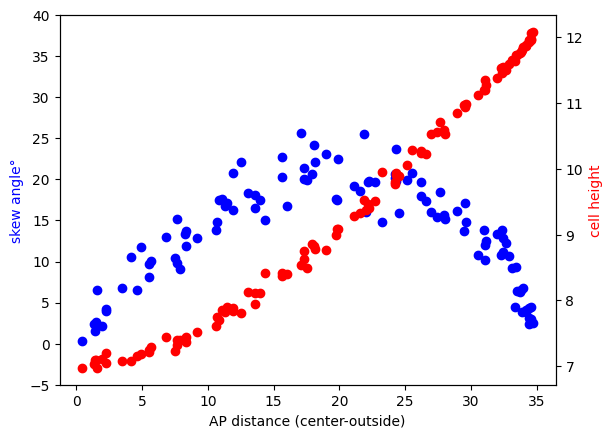

In [266]:
fig, ax =plt.subplots()

ax.scatter(np.abs(np.array(z_pos)), np.abs(angle), c="blue")
ax.set_ylim(-5,40)
ax.set_xlabel("AP distance (center-outside)", )
ax.set_ylabel("skew angle°", c="blue")

ax2 = ax.twinx()
ax2.scatter( np.abs(np.array(z_pos)), cell_height, c="red")
ax2.set_ylabel("cell height", c="red")

In [268]:
np.min(cell_height)

6.974083843397717

In [416]:
len(np.unique(mono_ellipso.edge_df[(mono_ellipso.edge_df['face'].isin(mono_ellipso.face_df[mono_ellipso.face_df['num_sides']==3].index)) &
                  (mono_ellipso.edge_df['segment']=='lateral')] ['cell']))
        

0

33.0